In [20]:
import sys
sys.path.append(r"C:\Users\ASUS\Desktop\Siyathma 7th sem\FYP\Research")
import numpy as np
from graph_encoders.wl import WL

np.random.seed(42)

In [22]:
print('Loading NCI1 dataset')

graphs = []
y = []

filepath = r"C:\Users\ASUS\Desktop\Siyathma 7th sem\FYP\Research\datasets\NCI_full\1total-connect.sdf"
supplier = Chem.SDMolSupplier(filepath, sanitize=False, removeHs=False)
for mol in supplier:
    if mol is None:
        continue

    G = nx.Graph()

    # Add atoms as nodes
    for atom in mol.GetAtoms():
        G.add_node(
            atom.GetIdx(),
            label=atom.GetSymbol()   # WL uses node labels
        )

    # Add bonds as edges
    for bond in mol.GetBonds():
        G.add_edge(
            bond.GetBeginAtomIdx(),
            bond.GetEndAtomIdx()
        )

    # Get graph label
    # In NCI1, class label is stored as a molecule property
    label = int(float(mol.GetProp("value")))
    graphs.append(G)


    y.append(label)

print(f"Loaded {len(graphs)} graphs")

Loading NCI1 dataset
Loaded 37349 graphs


In [24]:
wl = WL(
    wl_iterations=2
)

documents = wl.create_wl_hash(graphs)

In [25]:
from collections import Counter

raw_counter = Counter()

for doc in documents:
    raw_counter.update(doc.words)

In [26]:
from collections import Counter

all_words = []

for doc in documents:
    all_words.extend(doc.words)

raw_freq = Counter(all_words)

# Top 20 most common subtrees
print(raw_freq.most_common(20))

[('4', 457711), ('5', 309225), ('f4490329afa6428ebf9afd9005f27abf', 205684), ('3', 189441), ('9dafdb095db58e4fb4a689fb082bb849', 125097), ('0cce1d019f4dfe3f7e302db488dffe57', 111735), ('af67ad2ffa467c8bad3f840d7c715bb0', 84303), ('daf0ea2428a35efce0f888355b911b7b', 76201), ('d2f28a9d851e79d522463d5b5186f3f8', 68559), ('101640cf30a7e8aa5631df7b2fe6afba', 60884), ('0c823a59055acdfdb3984bf1e8af3203', 41467), ('7fdb9950685020307dbcc84ed2feae5d', 41467), ('b3a2337249583f88e793adf89f051b5c', 40610), ('801f34fb20fa19a400c8178a3c9a04e3', 34684), ('6c7ad2f62b6c2e570f3f66bf94445d25', 32186), ('83330c87ecc2517466a49ffe3555fd98', 31623), ('59fffba59cd5808102e1b6dc26f44c3c', 26768), ('97b76f1a9373332c0e005a2feabf0f5d', 26659), ('7afcb8896ce267d8a87338ff310f2278', 26136), ('4025f7ec584c225eb214f61e8fa3aaba', 25107)]


In [ ]:
trimmed_words = [word for word, _ in vocab]

trimmed_freq = {word: raw_freq[word] for word in trimmed_words}

print(list(trimmed_freq.items())[:20])

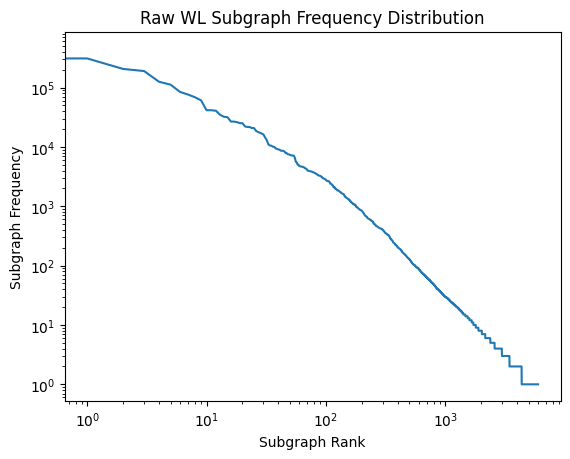

In [28]:
import matplotlib.pyplot as plt

freqs = sorted(raw_counter.values(), reverse=True)

plt.plot(freqs)
plt.xscale("log")
plt.yscale("log")

# Labels and title
plt.xlabel("Subgraph Rank")
plt.ylabel("Subgraph Frequency")
plt.title("Raw WL Subgraph Frequency Distribution")

plt.show()


In [ ]:
X_final = X_norm

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Use SAME split always
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

preds = model.predict(X_test)
acc = accuracy_score(y_test, preds)

print("Accuracy (baseline):", acc)